In [1]:
# akses file data yang ada di Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# import semua pustaka yang dibutuhkan
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [3]:
# Load file CSV dari folder Drive dan membaca file CSV dari Google Drive
df = pd.read_csv('/content/drive/MyDrive/MY SEMEST8R/DATA VALID/HASIL DATA PER DESA.csv')

In [4]:
# Mengecek apakah struktur data sudah benar dan melihat nama kolom dan beberapa nilai awal data
print(df.head())

   Tahun  Bulan   RUTE-DESA  KONSUMSI
0   2022      1  RUTE: A101     12752
1   2022      1  RUTE: A102     14542
2   2022      1  RUTE: A103      4310
3   2022      1  RUTE: A104     20587
4   2022      1  RUTE: A105      4646


In [5]:
# Memastikan nama kolom di dataset
print(df.columns)

Index(['Tahun', 'Bulan', 'RUTE-DESA', 'KONSUMSI'], dtype='object')


In [6]:
# df.copy() — amanin supaya operasi selanjutnya tidak merubah df asli secara tidak sengaja
# astype(str) — ubah kolom Tahun dan Bulan jadi string
# str.zfill(2) — pastikan Bulan seperti 1 jadi 01, biar format tanggal valid
# '01' — karena datanya bulanan, kita set selalu ke tanggal 1 tiap bulannya
# pd.to_datetime(...) — ubah string jadi objek tanggal datetime64
# print(df.dtypes) — ngecek apakah Tanggal udah jadi datetime, bagus banget

df = df.copy()
df['Tanggal'] = pd.to_datetime(df['Tahun'].astype(str) + '-' + df['Bulan'].astype(str).str.zfill(2) + '-01')

# Cek hasilnya
print(df[['Tahun', 'Bulan', 'Tanggal']].head())

# Cek tipe data tiap kolom
print(df.dtypes)

   Tahun  Bulan    Tanggal
0   2022      1 2022-01-01
1   2022      1 2022-01-01
2   2022      1 2022-01-01
3   2022      1 2022-01-01
4   2022      1 2022-01-01
Tahun                 int64
Bulan                 int64
RUTE-DESA            object
KONSUMSI              int64
Tanggal      datetime64[ns]
dtype: object


In [7]:
# Menjadikan kolom Tanggal sebagai indeks time series
# Langkah: Set 'Tanggal' sebagai index

df = df.set_index('Tanggal')
df = df.sort_index()

In [8]:
# Memfilter data berdasarkan RUTE, dalam hal ini RUTE: A105
# Menyimpan hasilnya di df_rute agar bisa fokus analisis hanya untuk rute itu

df_rute = df[df['RUTE-DESA'] == 'RUTE: A105'].copy()
print(df_rute.head())
print(f"Jumlah data rute A105: {len(df_rute)}")

            Tahun  Bulan   RUTE-DESA  KONSUMSI
Tanggal                                       
2022-01-01   2022      1  RUTE: A105      4646
2022-02-01   2022      2  RUTE: A105      4526
2022-03-01   2022      3  RUTE: A105      5082
2022-04-01   2022      4  RUTE: A105      4144
2022-05-01   2022      5  RUTE: A105      4210
Jumlah data rute A105: 36


In [9]:
df_rute = df_rute.sort_index()

In [10]:
series_a105 = df_rute['KONSUMSI']
print(series_a105.index)

DatetimeIndex(['2022-01-01', '2022-02-01', '2022-03-01', '2022-04-01',
               '2022-05-01', '2022-06-01', '2022-07-01', '2022-08-01',
               '2022-09-01', '2022-10-01', '2022-11-01', '2022-12-01',
               '2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01',
               '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01',
               '2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01',
               '2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
               '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', name='Tanggal', freq=None)


In [11]:
# Slicing data Training dan Testing
# Misal series_a105 adalah time series untuk RUTE A105 (index datetime dan kolom konsumsi air)

n_total = len(series_a105)
n_train = int(0.7 * n_total)  # ambil 70% untuk training

# Bagi data
train = series_a105.iloc[:n_train]
test = series_a105.iloc[n_train:]

# Cek hasil
print(f"Jumlah total data     : {n_total}")
print(f"Jumlah data training  : {len(train)}")
print(f"Jumlah data testing   : {len(test)}")
print(f"\nPeriode training: {train.index[0]} sampai {train.index[-1]}")
print(f"Periode testing : {test.index[0]} sampai {test.index[-1]}")

Jumlah total data     : 36
Jumlah data training  : 25
Jumlah data testing   : 11

Periode training: 2022-01-01 00:00:00 sampai 2024-01-01 00:00:00
Periode testing : 2024-02-01 00:00:00 sampai 2024-12-01 00:00:00


In [12]:
from statsmodels.tsa.stattools import adfuller

# Uji ADF untuk data latih
adf_result = adfuller(train.dropna())

# Tampilkan hasil
print("Hasil Uji Stasioneritas (ADF Test) pada Data Latih:")
print(f"ADF Statistic     : {adf_result[0]}")
print(f"p-value           : {adf_result[1]}")
print("Critical Values   :")
for key, value in adf_result[4].items():
    print(f"   {key} : {value}")

# Interpretasi awal
if adf_result[1] <= 0.05:
    print(" Data sudah stasioner (p-value <= 0.05)")
else:
    print(" Data belum stasioner (p-value > 0.05), perlu differencing")

Hasil Uji Stasioneritas (ADF Test) pada Data Latih:
ADF Statistic     : -5.031634749281208
p-value           : 1.9206592427723335e-05
Critical Values   :
   1% : -3.7377092158564813
   5% : -2.9922162731481485
   10% : -2.635746736111111
 Data sudah stasioner (p-value <= 0.05)


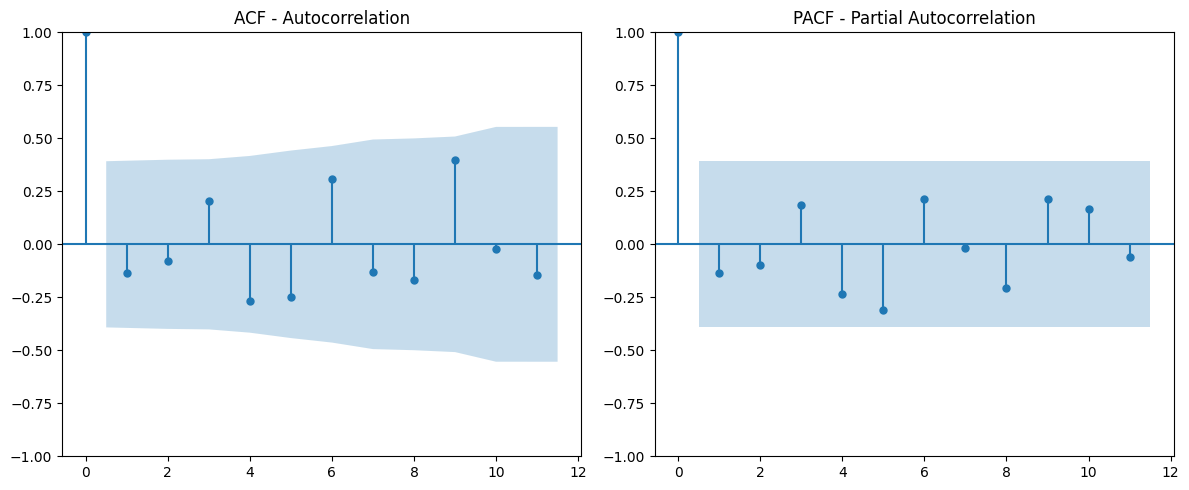

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_acf(train, ax=plt.gca(), lags=11)  # plot langsung data train
plt.title("ACF - Autocorrelation")

plt.subplot(1, 2, 2)
plot_pacf(train, ax=plt.gca(), lags=11, method='ywm')  # plot langsung data train
plt.title("PACF - Partial Autocorrelation")

plt.tight_layout()
plt.show()

In [14]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error
import warnings

# Supaya warning ARIMA gak banyak muncul
warnings.filterwarnings('ignore')

def grid_search_arima_fixed_d(series, d=0, p_max=3, q_max=3, route_label=''):
    best_aic = np.inf
    best_order = None
    best_model = None
    best_mape = np.inf

    for p in range(1, p_max + 1):
        for q in range(1, q_max + 1):
            try:
                print(f'Mencoba ARIMA({p},{d},{q}) untuk RUTE {route_label}')
                model = ARIMA(series, order=(p, d, q))
                model_fit = model.fit()

                pred = model_fit.fittedvalues
                mape = mean_absolute_percentage_error(series[d:], pred[d:]) * 100

                print(f'--> MAPE: {mape:.2f}%, AIC: {model_fit.aic:.2f}')

                if model_fit.aic < best_aic:
                    best_aic = model_fit.aic
                    best_order = (p, d, q)
                    best_model = model_fit
                    best_mape = mape
                    print('Model ini disimpan sebagai terbaik sementara')

            except Exception as e:
                print(f' ARIMA({p},{d},{q}) gagal: {e}')
                continue

    return best_order, best_model, best_aic, best_mape
# Jalankan grid search
best_order_a105, best_model_a105, best_aic_a105, best_mape_a105 = grid_search_arima_fixed_d(series=series_a105,
    d=0,
    p_max=3,
    q_max=3,
    route_label='A105'
)

# Cetak hasil terbaik
print('\n Hasil Grid Search ARIMA RUTE A105')
print(f'Best (p,d,q): {best_order_a105}')
print(f'Best AIC   : {best_aic_a105:.2f}')
print(f'Best MAPE  : {best_mape_a105:.2f}%')
print('\nRingkasan Model Terbaik:')
print(best_model_a105.summary())

Mencoba ARIMA(1,0,1) untuk RUTE A105
--> MAPE: 9.74%, AIC: 552.73
Model ini disimpan sebagai terbaik sementara
Mencoba ARIMA(1,0,2) untuk RUTE A105
--> MAPE: 9.53%, AIC: 553.43
Mencoba ARIMA(1,0,3) untuk RUTE A105
--> MAPE: 9.33%, AIC: 554.57
Mencoba ARIMA(2,0,1) untuk RUTE A105
--> MAPE: 9.68%, AIC: 554.06
Mencoba ARIMA(2,0,2) untuk RUTE A105
--> MAPE: 9.20%, AIC: 552.14
Model ini disimpan sebagai terbaik sementara
Mencoba ARIMA(2,0,3) untuk RUTE A105
--> MAPE: 9.12%, AIC: 556.01
Mencoba ARIMA(3,0,1) untuk RUTE A105
--> MAPE: 8.92%, AIC: 553.03
Mencoba ARIMA(3,0,2) untuk RUTE A105
--> MAPE: 8.93%, AIC: 555.03
Mencoba ARIMA(3,0,3) untuk RUTE A105
--> MAPE: 7.97%, AIC: 551.89
Model ini disimpan sebagai terbaik sementara

 Hasil Grid Search ARIMA RUTE A105
Best (p,d,q): (3, 0, 3)
Best AIC   : 551.89
Best MAPE  : 7.97%

Ringkasan Model Terbaik:
                               SARIMAX Results                                
Dep. Variable:               KONSUMSI   No. Observations:          

In [15]:
# setelah dapat parameter ARIMA terbaik dari grid search
# Fit model ARIMA dengan parameter terbaik dan lakukan forecasting ke data test
# Fit ulang model dengan parameter terbaik hanya menggunakan data training
# Forecast ke periode data testing sebanyak panjang data test
# Hitung error evaluasi dengan data test asli (MAE, MSE, RMSE, MAPE)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Parameter terbaik dari grid search untuk A105
p, d, q = best_order_a105  # pastikan kamu sudah simpan hasilnya di variabel ini

# Fit model ARIMA pada data training A105 dengan parameter terbaik
model_best = ARIMA(train, order=(p, d, q))
model_best_fit = model_best.fit()

# Forecast untuk panjang data test A105
forecast_steps = len(test)
forecast = model_best_fit.forecast(steps=forecast_steps)

# Hitung metrik evaluasi
mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(test, forecast) * 100

print(f"Evaluasi hasil forecasting untuk RUTE A105:")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

Evaluasi hasil forecasting untuk RUTE A105:
MAE  : 864.66
MSE  : 862237.13
RMSE : 928.57
MAPE : 23.64%


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt

# Ambil parameter terbaik hasil grid search
p, d, q = best_order_a105

# Split data A105: train sampai Jan 2024, test Feb - Des 2024
train_end = '2024-01-01'
test_start = '2024-02-01'
test_end = '2024-12-01'

train = series_a105[:train_end]
test = series_a105[test_start:test_end]

# Fit model ARIMA terbaik
model_best = ARIMA(train, order=(p, d, q))
model_best_fit = model_best.fit()

# Forecast sejumlah data test
forecast_steps = len(test)
forecast = model_best_fit.forecast(steps=forecast_steps)
forecast.index = test.index  # supaya bisa dibandingkan langsung

# Evaluasi prediksi
mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(test, forecast) * 100

print(f"\n Evaluasi hasil forecasting untuk RUTE A105 (ARIMA{(p,d,q)}):")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")


 Evaluasi hasil forecasting untuk RUTE A105 (ARIMA(3, 0, 3)):
MAE  : 864.66
MSE  : 862237.13
RMSE : 928.57
MAPE : 23.64%


In [17]:
#  coba kombinasi (p,d,q) lain
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error
import warnings

# Supaya warning ARIMA gak banyak muncul
warnings.filterwarnings('ignore')

# 1. Tentukan manual parameter ARIMA
p = 3  # ganti sesuai keinginan
d = 0
q = 2

# 2. Fit model ke data training
model_manual = ARIMA(train, order=(p, d, q))
model_manual_fit = model_manual.fit()

# 3. Forecast sebanyak panjang data test
forecast_manual = model_manual_fit.forecast(steps=len(test))

# 4. Evaluasi
mape_manual = mean_absolute_percentage_error(test, forecast_manual) * 100
aic_manual = model_manual_fit.aic

# 5. Tampilkan hasil
print(f'ARIMA({p},{d},{q})')
print(f'AIC  : {aic_manual:.2f}')
print(f'MAPE : {mape_manual:.2f}%')

ARIMA(3,0,2)
AIC  : 370.81
MAPE : 21.98%


In [18]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# 1. Fit model ARIMA(3,0,2) ke data training
model_302 = ARIMA(train, order=(3, 0, 2))
model_302_fit = model_302.fit()

# 2. Forecast sepanjang data testing
forecast_302 = model_302_fit.forecast(steps=len(test))
forecast_302.index = test.index  # Tambahan ini supaya forecast sejajar dengan test

# 3. Hitung metrik evaluasi
mae = mean_absolute_error(test, forecast_302)
mse = mean_squared_error(test, forecast_302)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(test, forecast_302) * 100
aic = model_302_fit.aic

# 4. Cetak hasil evaluasi
print("Evaluasi Forecasting ARIMA(3,0,2):")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"AIC  : {aic:.2f}")

Evaluasi Forecasting ARIMA(3,0,2):
MAE  : 800.98
MSE  : 794573.44
RMSE : 891.39
MAPE : 21.98%
AIC  : 370.81


In [19]:
# Fit model ARIMA terbaik
model_final = ARIMA(series_a105, order=(3, 0, 2))
model_final_fit = model_final.fit()

# Buat index tanggal untuk 24 bulan ke depan
last_date = series_a105.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')

# Forecast mentah dulu
forecast_raw =  model_final_fit.forecast(steps=24)
print(forecast_raw)

# Baru setelah itu, kita potong nilai negatif jadi nol
forecast = forecast_raw.clip(lower=0)

# Simpan dalam DataFrame
forecast_df = pd.DataFrame({
    'Forecast_Konsumsi': forecast
}, index=pd.date_range(start='2025-01-01', periods=24, freq='MS'))

# Forecast
forecast_24bulan = model_final_fit.forecast(steps=24)

# Simpan hasil ke DataFrame
df_forecast_24 = pd.DataFrame({
    'Tanggal': future_dates,
    'Forecast_Konsumsi': forecast_24bulan
})
df_forecast_24.set_index('Tanggal', inplace=True)
df_forecast_24['Forecast_Konsumsi'] = df_forecast_24['Forecast_Konsumsi'].apply(lambda x: max(x, 0))

# Lihat hasilnya
print(df_forecast_24)

2025-01-01    3681.753056
2025-02-01    3699.230130
2025-03-01    3649.455630
2025-04-01    3755.208811
2025-05-01    3793.666123
2025-06-01    3798.727166
2025-07-01    3848.020755
2025-08-01    3881.516072
2025-09-01    3900.854068
2025-10-01    3931.521669
2025-11-01    3958.097059
2025-12-01    3978.742389
2026-01-01    4001.479633
2026-02-01    4022.606757
2026-03-01    4040.986441
2026-04-01    4059.078516
2026-05-01    4076.102244
2026-06-01    4091.598436
2026-07-01    4106.322827
2026-08-01    4120.168770
2026-09-01    4132.996906
2026-10-01    4145.055076
2026-11-01    4156.370570
2026-12-01    4166.924027
Freq: MS, Name: predicted_mean, dtype: float64
            Forecast_Konsumsi
Tanggal                      
2025-01-01        3681.753056
2025-02-01        3699.230130
2025-03-01        3649.455630
2025-04-01        3755.208811
2025-05-01        3793.666123
2025-06-01        3798.727166
2025-07-01        3848.020755
2025-08-01        3881.516072
2025-09-01        3900.854068

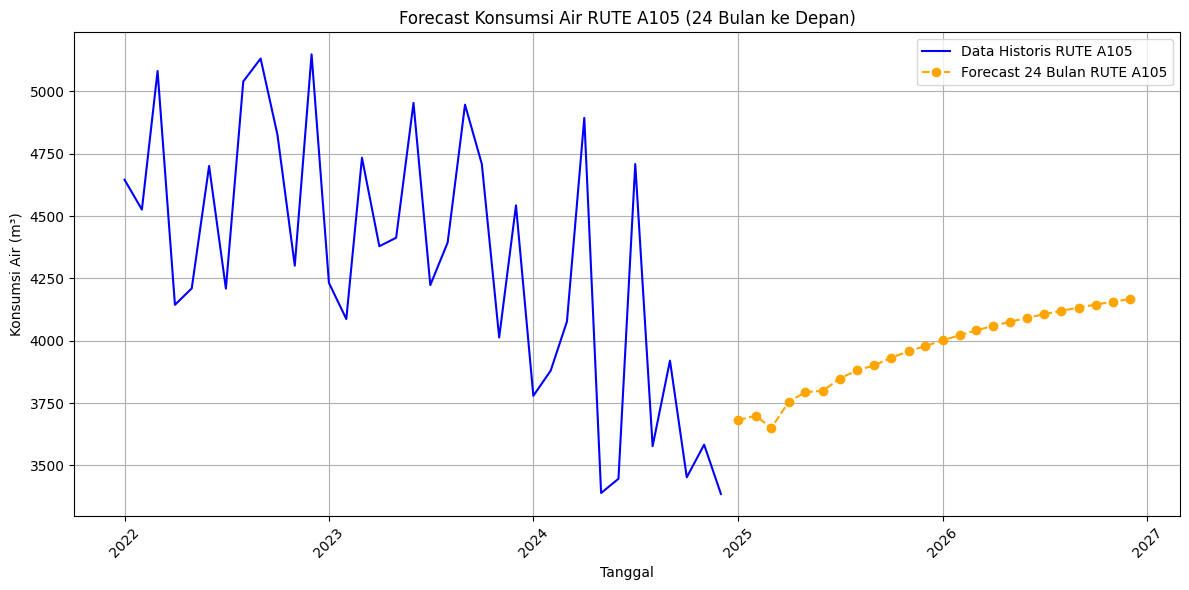

In [20]:
import matplotlib.pyplot as plt

# Pastikan data historis sudah ada dan indexnya datetime
plt.figure(figsize=(12,6))

# Plot data historis
plt.plot(series_a105.index, series_a105, label='Data Historis RUTE A105', color='blue')

# Plot hasil forecast, pastikan index forecast sudah datetime juga
plt.plot(forecast.index, forecast, label='Forecast 24 Bulan RUTE A105', color='orange', linestyle='--', marker='o')

plt.title('Forecast Konsumsi Air RUTE A105 (24 Bulan ke Depan)')
plt.xlabel('Tanggal')
plt.ylabel('Konsumsi Air (m³)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [21]:
print(forecast.head())
print(series_a105.head())
print(type(forecast))
print(type(series_a105))
print(forecast.index)
print(series_a105.index)

2025-01-01    3681.753056
2025-02-01    3699.230130
2025-03-01    3649.455630
2025-04-01    3755.208811
2025-05-01    3793.666123
Freq: MS, Name: predicted_mean, dtype: float64
Tanggal
2022-01-01    4646
2022-02-01    4526
2022-03-01    5082
2022-04-01    4144
2022-05-01    4210
Name: KONSUMSI, dtype: int64
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
DatetimeIndex(['2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01',
               '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01',
               '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01',
               '2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01',
               '2026-05-01', '2026-06-01', '2026-07-01', '2026-08-01',
               '2026-09-01', '2026-10-01', '2026-11-01', '2026-12-01'],
              dtype='datetime64[ns]', freq='MS')
DatetimeIndex(['2022-01-01', '2022-02-01', '2022-03-01', '2022-04-01',
               '2022-05-01', '2022-06-01', '2022-07-01', '2022-08-01',
 

In [22]:
series_a105 = series_a105.asfreq('MS')

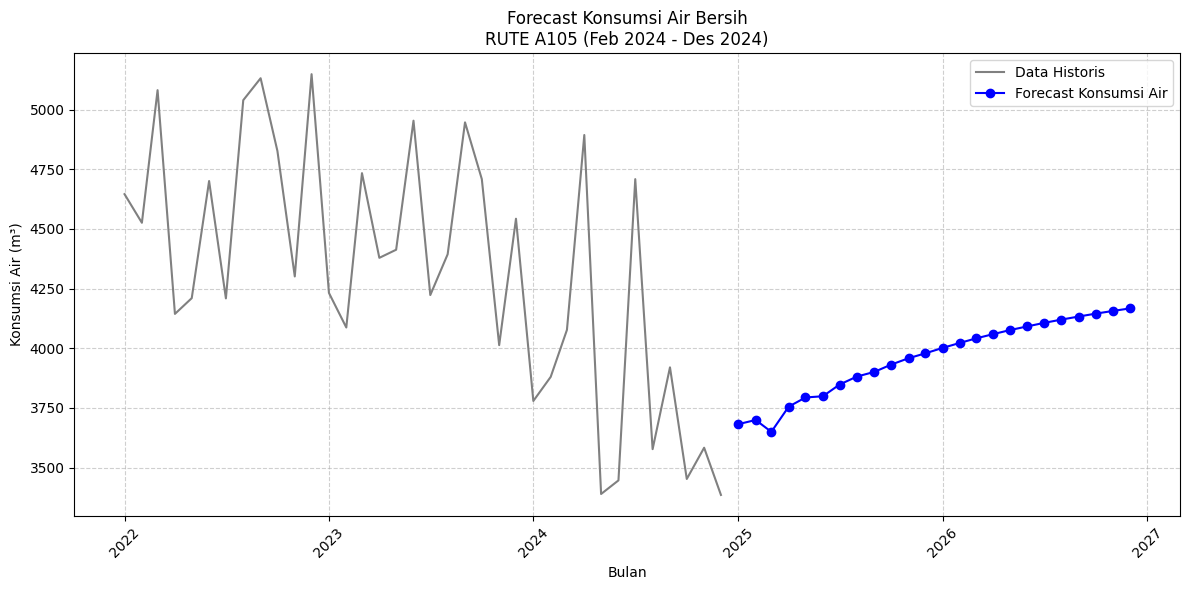

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(series_a105.index, series_a105, label='Data Historis', color='gray')

plt.plot(forecast.index, forecast, label='Forecast Konsumsi Air', color='blue', marker='o')

plt.title('Forecast Konsumsi Air Bersih\nRUTE A105 (Feb 2024 - Des 2024)')
plt.xlabel('Bulan')
plt.ylabel('Konsumsi Air (m³)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

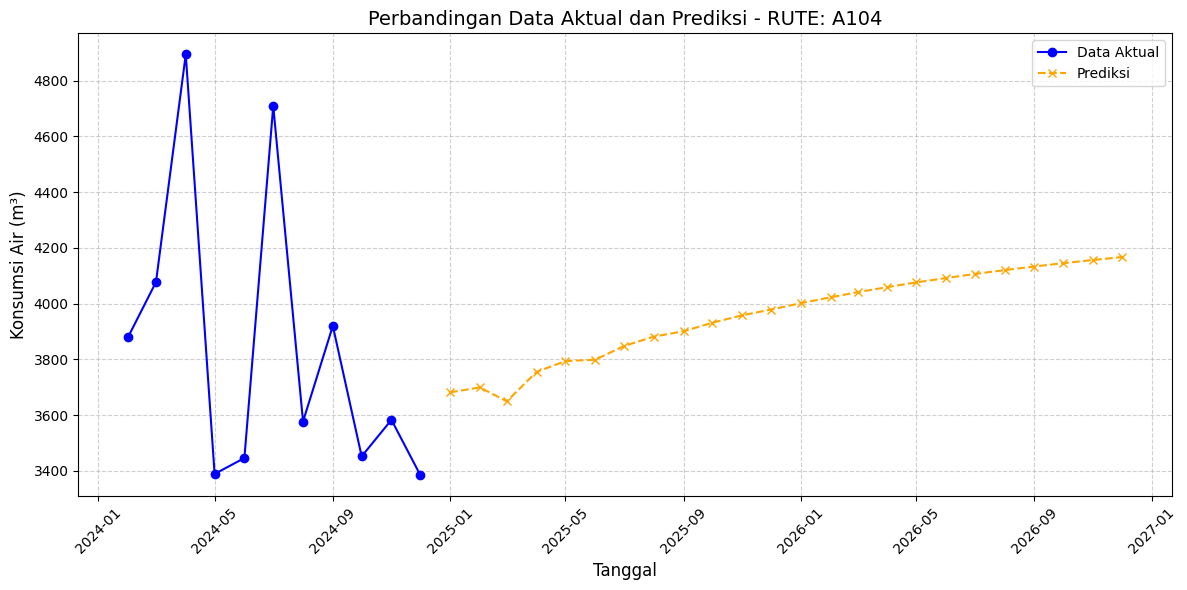

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Pastikan index datetime
test.index = pd.to_datetime(test.index)
forecast.index = pd.to_datetime(forecast.index)

plt.figure(figsize=(12, 6))

# Plot data aktual dengan marker bulat
plt.plot(test.index, test, label='Data Aktual', marker='o', color='blue')

# Plot data prediksi dengan marker silang dan garis putus-putus
plt.plot(forecast.index, forecast, label='Prediksi', marker='x', linestyle='--', color='orange')

plt.title('Perbandingan Data Aktual dan Prediksi - RUTE: A104', fontsize=14)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Konsumsi Air (m³)', fontsize=12)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Putar label tanggal supaya terbaca jelas
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

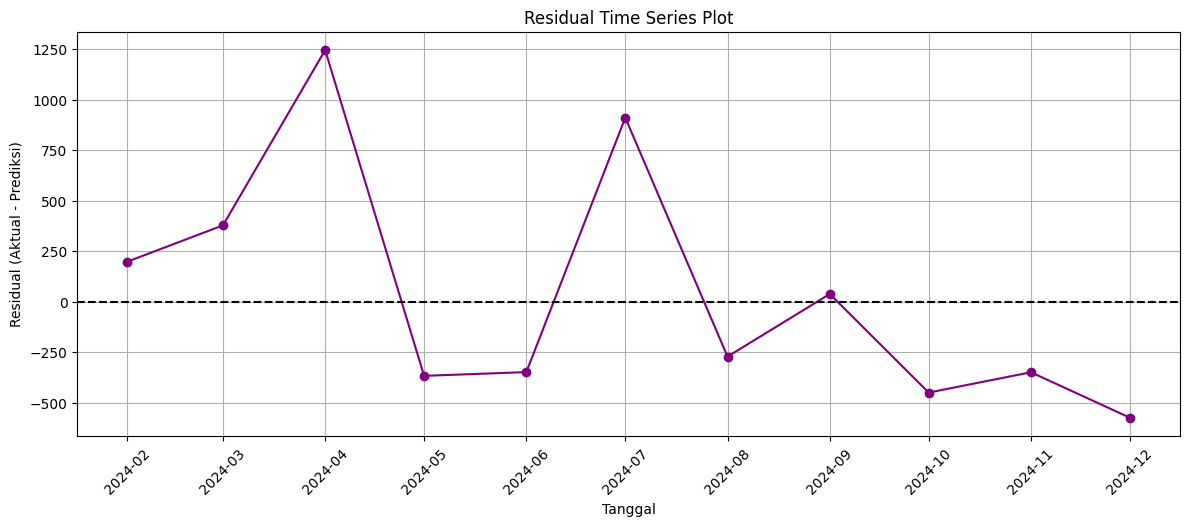

In [25]:
import matplotlib.pyplot as plt

# Pastikan panjang dan index cocok
min_len = min(len(test), len(forecast))
test_aligned = test[:min_len]
forecast_aligned = forecast[:min_len]
forecast_aligned.index = test_aligned.index  # pastikan index cocok

# Hitung residual
residuals = test_aligned - forecast_aligned

# Plot residual
plt.figure(figsize=(12,5))
plt.plot(residuals.index, residuals, marker='o', linestyle='-', color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.title('Residual Time Series Plot')
plt.xlabel('Tanggal')
plt.ylabel('Residual (Aktual - Prediksi)')
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

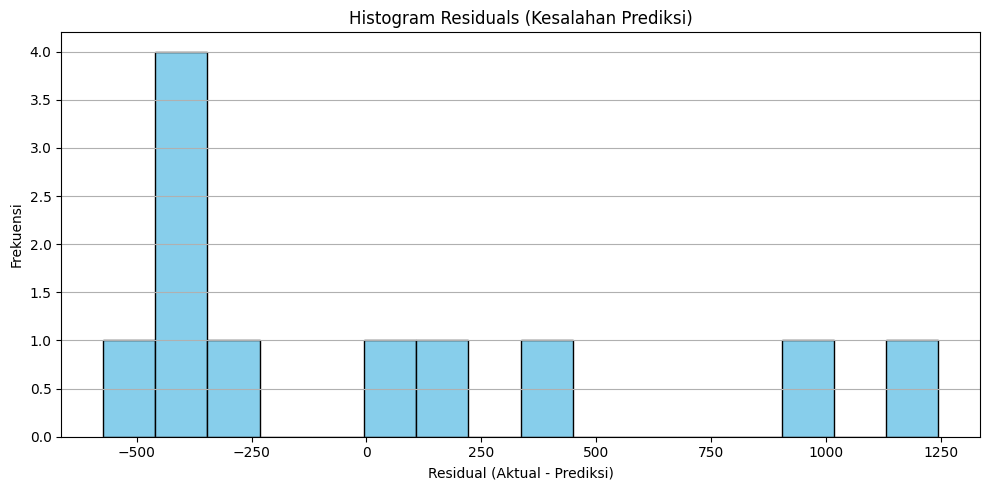

In [26]:
import matplotlib.pyplot as plt

# Samakan panjang dan index
min_len = min(len(test), len(forecast))
test_aligned = test[:min_len]
forecast_aligned = forecast[:min_len]
forecast_aligned.index = test_aligned.index

# Hitung residual
residuals = test_aligned - forecast_aligned
residuals_clean = residuals.dropna()

# Cek dulu residual valid gak
if residuals_clean.empty:
    print("Tidak ada residual valid (semua NaN atau nol). Histogram tidak bisa ditampilkan.")
else:
    # Plot histogram
    plt.figure(figsize=(10,5))
    plt.hist(residuals_clean, bins=16, color='skyblue', edgecolor='black')
    plt.title('Histogram Residuals (Kesalahan Prediksi)')
    plt.xlabel('Residual (Aktual - Prediksi)')
    plt.ylabel('Frekuensi')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

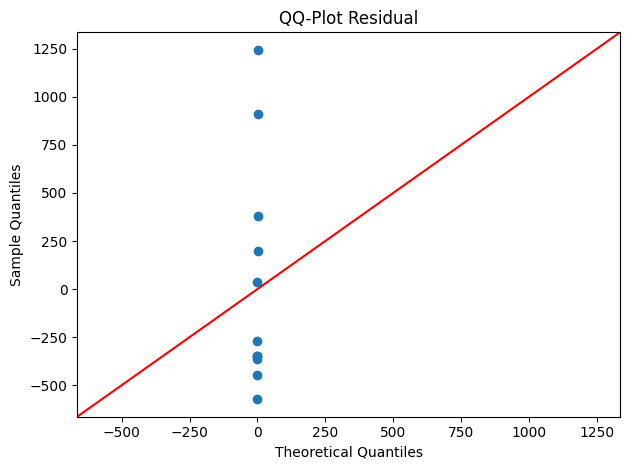

In [27]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Hitung residual dengan pastikan panjang dan index sama
min_len = min(len(test), len(forecast))
test_aligned = test[:min_len]
forecast_aligned = forecast[:min_len]
forecast_aligned.index = test_aligned.index

residuals = test_aligned - forecast_aligned
residuals_clean = residuals.dropna()

# Plot QQ-Plot jika residual tidak kosong
if residuals_clean.empty:
    print("Residual kosong, tidak bisa buat QQ-Plot.")
else:
    sm.qqplot(residuals_clean, line='45')
    plt.title('QQ-Plot Residual')
    plt.tight_layout()
    plt.show()

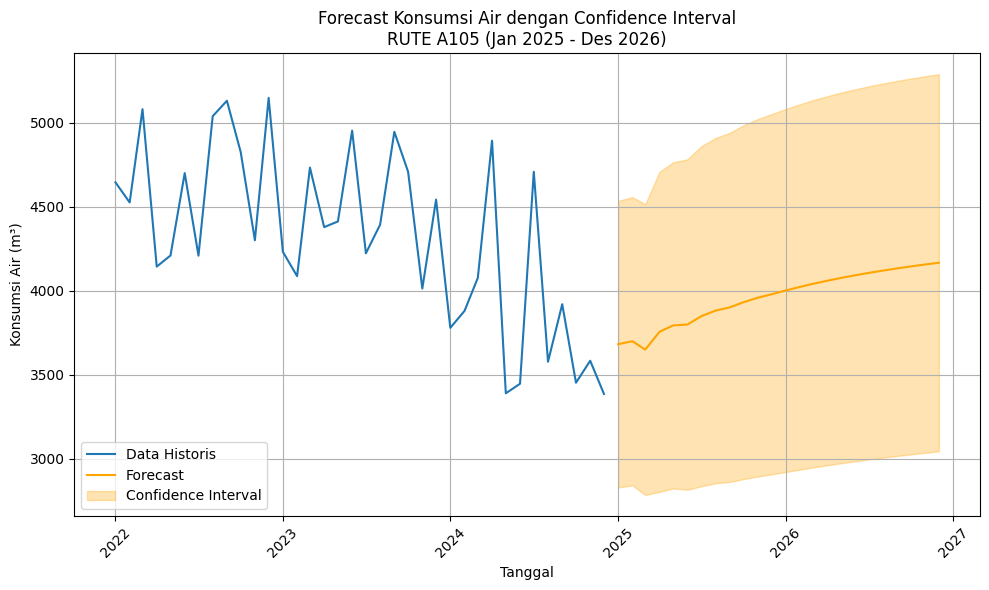

In [28]:
import matplotlib.pyplot as plt

# Langkah 1: Forecast 24 bulan ke depan
forecast_steps = 24  # Jan 2025 - Des 2026
model_final = ARIMA(series_a105[:'2024-12-01'], order=(3, 0, 2))  # Ganti (p,d,q) sesuai model terbaik
model_fit = model_final.fit()

# Langkah 2: Ambil hasil forecast & confidence interval
forecast_result = model_fit.get_forecast(steps=forecast_steps, alpha=0.25)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# Langkah 3: Atur index waktu untuk hasil forecast
last_date = series_a105.index[-1]
future_index = pd.date_range(start=last_date + pd.offsets.MonthBegin(), periods=forecast_steps, freq='MS')
forecast_mean.index = future_index
conf_int.index = future_index

# Langkah 4: Visualisasi
plt.figure(figsize=(10,6))
plt.plot(series_a105.index, series_a105, label='Data Historis')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', color='orange')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='orange', alpha=0.3, label='Confidence Interval')

plt.title('Forecast Konsumsi Air dengan Confidence Interval\nRUTE A105 (Jan 2025 - Des 2026)')
plt.xlabel('Tanggal')
plt.ylabel('Konsumsi Air (m³)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Evaluasi Model ARIMA(3,0,2) pada Data Test:
MAE  : 800.98
MSE  : 794573.44
RMSE : 891.39
MAPE : 21.98%

Forecast 24 Bulan ke Depan (Jan 2025 - Des 2026):
2025-01-01    3681.753056
2025-02-01    3699.230130
2025-03-01    3649.455630
2025-04-01    3755.208811
2025-05-01    3793.666123
2025-06-01    3798.727166
2025-07-01    3848.020755
2025-08-01    3881.516072
2025-09-01    3900.854068
2025-10-01    3931.521669
2025-11-01    3958.097059
2025-12-01    3978.742389
2026-01-01    4001.479633
2026-02-01    4022.606757
2026-03-01    4040.986441
2026-04-01    4059.078516
2026-05-01    4076.102244
2026-06-01    4091.598436
2026-07-01    4106.322827
2026-08-01    4120.168770
2026-09-01    4132.996906
2026-10-01    4145.055076
2026-11-01    4156.370570
2026-12-01    4166.924027
Freq: MS, Name: predicted_mean, dtype: float64


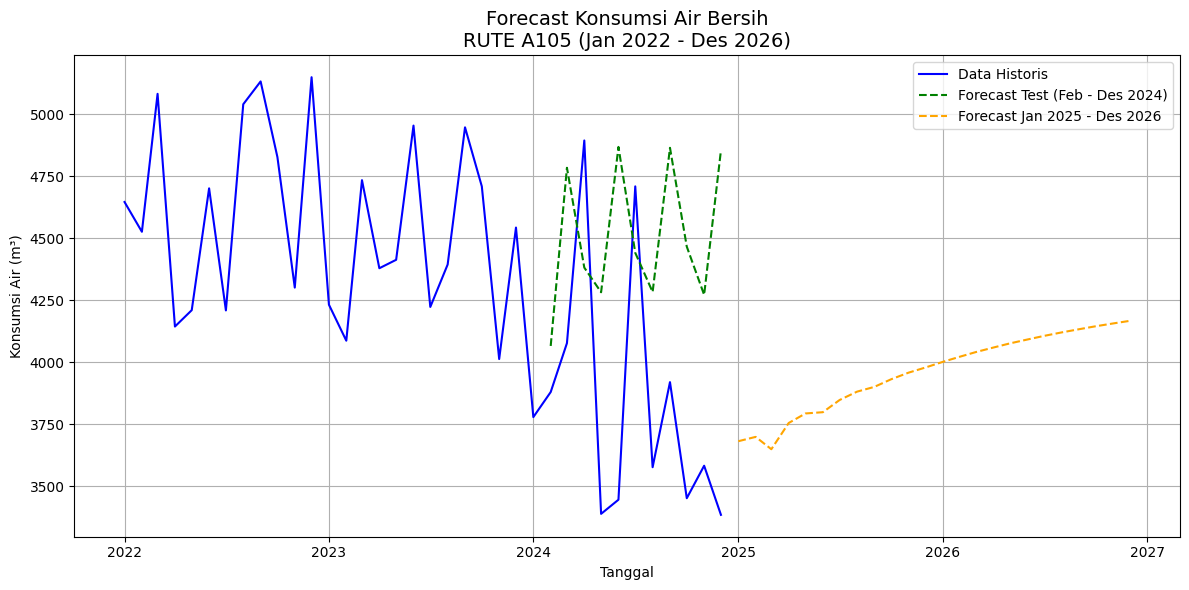

File forecast_rute_a105.csv berhasil disimpan.


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import pickle

# 1. Filter Data untuk RUTE A102
series_a105 = df[df['RUTE-DESA'] == 'RUTE: A105']['KONSUMSI']

# 2. Preprocessing
series_a105.index = pd.to_datetime(series_a105.index)
series_a105 = series_a105.asfreq('MS')
series_a105 = series_a105.interpolate()

# 3. Split Data Train-Test
train_end = '2024-01-01'
test_start = '2024-02-01'
test_end = '2024-12-01'

train = series_a105[:train_end]
test = series_a105[test_start:test_end]

# 4. Fit Model ARIMA ke data training
model = ARIMA(train, order=(3, 0, 2))
model_fit = model.fit()

# 5. Forecast untuk periode test
forecast_test = model_fit.predict(start=test_start, end=test_end, typ='levels')
forecast_test.index = test.index  # pastikan index cocok

# 6. Evaluasi Model
mae = mean_absolute_error(test, forecast_test)
mse = mean_squared_error(test, forecast_test)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(test, forecast_test) * 100

print('Evaluasi Model ARIMA(3,0,2) pada Data Test:')
print(f'MAE  : {mae:.2f}')
print(f'MSE  : {mse:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'MAPE : {mape:.2f}%')

# 7. Refit model dengan data lengkap hingga Desember 2024
full_series = series_a105[:test_end]
model_full = ARIMA(full_series, order=(3, 0, 2))
model_fit_full = model_full.fit()

# 8. Forecast 24 Bulan ke Depan (Jan 2025 - Des 2026)
steps_future = 24
forecast_future = model_fit_full.forecast(steps=steps_future)
future_index = pd.date_range(start=full_series.index[-1] + pd.offsets.MonthBegin(),
                             periods=steps_future, freq='MS')
forecast_future.index = future_index

print('\nForecast 24 Bulan ke Depan (Jan 2025 - Des 2026):')
print(forecast_future)

# 9. Visualisasi
plt.figure(figsize=(12,6))
plt.plot(series_a105.index, series_a105, label='Data Historis', color='blue')
plt.plot(forecast_test.index, forecast_test, label='Forecast Test (Feb - Des 2024)', linestyle='--', color='green')
plt.plot(forecast_future.index, forecast_future, label='Forecast Jan 2025 - Des 2026', linestyle='--', color='orange')
plt.title('Forecast Konsumsi Air Bersih\nRUTE A105 (Jan 2022 - Des 2026)', fontsize=14)
plt.xlabel('Tanggal')
plt.ylabel('Konsumsi Air (m³)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Anggap forecast_future itu hasil dari model.predict()
forecast = forecast_future.reset_index()
forecast.columns = ['Tanggal', 'Forecast']  # pastikan nama kolomnya rapi

# Simpan ke CSV langsung ke Google Drive
forecast['RUTE'] = 'A105'
forecast.to_csv('/content/drive/MyDrive/MY SEMEST8R/GCOLLAB/forecast_rute_a105.csv', index=False)

print("File forecast_rute_a105.csv berhasil disimpan.")


In [31]:
from google.colab import files
import shutil

shutil.copy('/content/drive/MyDrive/MY SEMEST8R/GCOLLAB/forecast_rute_a105.csv', '/content/forecast_rute_a105.csv')
files.download('forecast_rute_a105.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/MY SEMEST8R/GCOLLAB/forecast_rute_a105.csv')
print(df.head())
print(df.dtypes)

      Tanggal     Forecast  RUTE
0  2025-01-01  3681.753056  A105
1  2025-02-01  3699.230130  A105
2  2025-03-01  3649.455630  A105
3  2025-04-01  3755.208811  A105
4  2025-05-01  3793.666123  A105
Tanggal      object
Forecast    float64
RUTE         object
dtype: object
